# 09 — LIME et comparaison avec SHAP

## 🎯 Objectif

Appliquer **LIME** (Ribeiro et al. 2016) sur les **mêmes cas SOC** que SHAP, et **comparer** rigoureusement les deux méthodes XAI.

## Question scientifique

> **"Deux méthodes XAI fondées sur des principes différents donnent-elles des explications cohérentes ?"**

## 📋 Plan

1. Setup + chargement modèle XGBoost + données SHAP existantes
2. Création du LIME explainer (avec background du train set)
3. **Explications LIME** sur les 4 cas SOC (mêmes indices que SHAP)
4. **Comparaison SHAP vs LIME** par cas : top features, overlap, corrélation
5. **Métrique d'accord global** sur un panel de 50 cas aléatoires
6. Sauvegarde pour notebook 10

## ⏱️ Temps estimé

**~5 à 10 minutes**. LIME est plus lent que TreeSHAP (~1-3s par instance).

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from time import time
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from lime.lime_tabular import LimeTabularExplainer

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')
RESULTS_XAI = Path('../results/xai')

SEED = 42
np.random.seed(SEED)

print('✅ Setup terminé')

✅ Setup terminé


## 2. Chargement du modèle, des données et des résultats SHAP

In [2]:
# Modèle XGBoost
xgb_model = joblib.load(RESULTS_MODELS / 'xgb_optimized.joblib')

# Données
df = pd.read_parquet(DATA_PROCESSED / 'cic-ids-2017_clean.parquet')
with open(DATA_PROCESSED / 'label_mapping.json') as f:
    label_mapping = json.load(f)
label_mapping = {int(k): v for k, v in label_mapping.items()}
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

y = df['Label_encoded'].values
feature_cols = [c for c in df.columns if c not in ['Label', 'Label_encoded']]
X = df[feature_cols].values.astype(np.float32)

# Même split que les autres notebooks
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85,
    stratify=y_trainval, random_state=SEED,
)

# Chargement du sample SHAP (pour utiliser EXACTEMENT les mêmes cas)
shap_data = np.load(RESULTS_XAI / 'shap_values_xgb.npz')
shap_values = shap_data['shap_values']
X_sample = shap_data['X_sample']
y_sample = shap_data['y_sample']
y_sample_pred = shap_data['y_sample_pred']
indices = shap_data['indices']

print(f'✅ Modèle XGBoost chargé')
print(f'✅ Sample SHAP chargé : {X_sample.shape}')
print(f'✅ SHAP values : {shap_values.shape}')

✅ Modèle XGBoost chargé
✅ Sample SHAP chargé : (5123, 77)
✅ SHAP values : (5123, 77, 7)


## 3. Création du LIME Explainer

### 📚 Le rôle du "background"

LIME a besoin d'un dataset de référence pour :
- Estimer les distributions des features
- Générer des perturbations réalistes autour d'une instance à expliquer

On utilise un échantillon de **5000 lignes du train set** comme background (suffisant statistiquement, rapide à instancier).

In [3]:
# Background : 5000 lignes aléatoires du train
n_background = 5000
bg_indices = np.random.choice(len(X_train), n_background, replace=False)
X_background = X_train[bg_indices]

explainer_lime = LimeTabularExplainer(
    training_data=X_background,
    feature_names=feature_cols,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True,
    random_state=SEED,
)

print(f'✅ LIME Explainer créé')
print(f'   Background : {n_background:,} lignes du train set')

✅ LIME Explainer créé
   Background : 5,000 lignes du train set


## 4. Récupération des indices des 4 cas SOC (mêmes que SHAP)

### 📚 Pourquoi reprendre les mêmes cas ?

Pour qu'une comparaison SHAP/LIME soit scientifiquement valable, on doit travailler sur **les mêmes instances exactes**. Sinon on compare des pommes et des oranges.

In [4]:
def find_case_idx(true_class, pred_class):
    """Trouve un index dans le sample SHAP."""
    true_idx = class_names.index(true_class)
    pred_idx = class_names.index(pred_class)
    mask = (y_sample == true_idx) & (y_sample_pred == pred_idx)
    found = np.where(mask)[0]
    return found[0] if len(found) > 0 else None

# Mêmes 4 cas que le notebook SHAP
case_a = find_case_idx('DDoS', 'DDoS')
case_b = find_case_idx('Bot', 'Bot')
case_c = find_case_idx('BENIGN', 'Bot')

# Cas D : confusion attaque (pas BENIGN) qui n'est pas dans la bonne classe
mask_attack = (y_sample != class_names.index('BENIGN'))
mask_wrong = (y_sample != y_sample_pred)
candidates_d = np.where(mask_attack & mask_wrong)[0]
case_d = candidates_d[0] if len(candidates_d) > 0 else None

cases = {
    'Cas A (TP DDoS)': case_a,
    'Cas B (TP Bot)': case_b,
    'Cas C (FP BENIGN→Bot)': case_c,
    'Cas D (Misclassification)': case_d,
}

print('📋 Cas SOC (identiques au notebook SHAP) :')
for label, idx in cases.items():
    if idx is not None:
        true_cls = label_mapping[y_sample[idx]]
        pred_cls = label_mapping[y_sample_pred[idx]]
        print(f'  {label:30s} : index={idx} | Vrai={true_cls}, Prédit={pred_cls}')

📋 Cas SOC (identiques au notebook SHAP) :
  Cas A (TP DDoS)                : index=4255 | Vrai=DDoS, Prédit=DDoS
  Cas B (TP Bot)                 : index=4155 | Vrai=Bot, Prédit=Bot
  Cas C (FP BENIGN→Bot)          : index=1398 | Vrai=BENIGN, Prédit=Bot
  Cas D (Misclassification)      : index=5122 | Vrai=Web Attack, Prédit=DoS


## 5. Génération des explications LIME pour chaque cas


  CAS : Cas A (TP DDoS)
  Vraie classe   : DDoS
  Classe prédite : DDoS
  Temps LIME     : 1.7s

📊 Top 10 features LIME (vers "DDoS") :
  53.00 < Destination Port <= 80.00                  : +0.0041
  Idle Std > 0.00                                    : +0.0030
  0.00 < Fwd Packet Length Std <= 72.74              : +0.0028
  min_seg_size_forward <= 20.00                      : +0.0027
  Bwd Packet Length Std > 317.16                     : +0.0025
  Active Mean > 0.00                                 : +0.0023
  Idle Max > 0.00                                    : +0.0022
  12.00 < Total Length of Fwd Packets <= 68.00       : +0.0021
  3.00 < Bwd IAT Min <= 47.00                        : +0.0019
  Flow Duration > 5476388.75                         : +0.0019


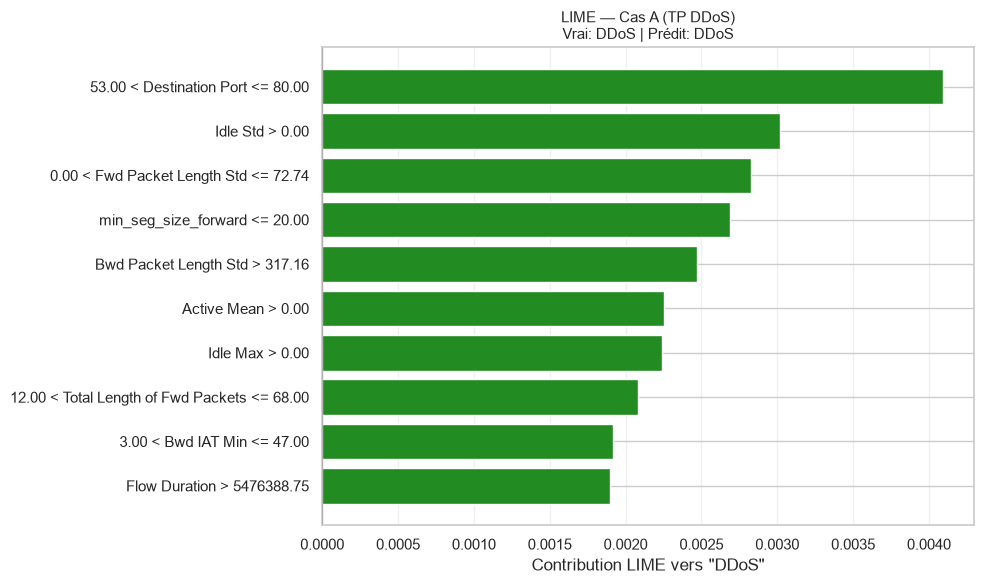


  CAS : Cas B (TP Bot)
  Vraie classe   : Bot
  Classe prédite : Bot
  Temps LIME     : 0.2s

📊 Top 10 features LIME (vers "Bot") :
  -1.00 < Init_Win_bytes_backward <= 0.00            : +0.0038
  0.00 < Bwd IAT Std <= 29481.18                     : +0.0037
  2.00 < Subflow Bwd Packets <= 5.00                 : +0.0032
  2.00 < Total Backward Packets <= 5.00              : +0.0031
  0.00 < Fwd IAT Std <= 817635.38                    : +0.0018
  2.00 < Total Fwd Packets <= 6.00                   : +0.0017
  64.00 < Fwd Header Length <= 152.00                : +0.0017
  ECE Flag Count <= 0.00                             : +0.0008
  CWE Flag Count <= 0.00                             : +0.0005
  Fwd URG Flags <= 0.00                              : +0.0004


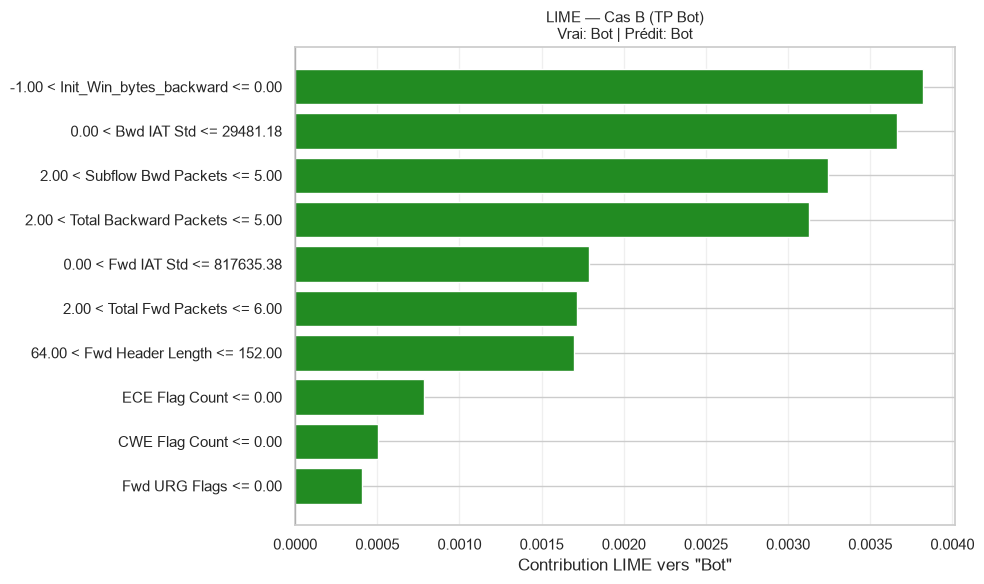


  CAS : Cas C (FP BENIGN→Bot)
  Vraie classe   : BENIGN
  Classe prédite : Bot
  Temps LIME     : 0.1s

📊 Top 10 features LIME (vers "Bot") :
  URG Flag Count > 0.00                              : +0.0024
  Destination Port > 443.00                          : +0.0014
  4.00 < Flow IAT Min <= 67.00                       : +0.0012
  Bwd Packets/s > 1773.12                            : +0.0011
  Subflow Fwd Bytes <= 12.00                         : +0.0011
  Packet Length Variance <= 5.33                     : +0.0011
  Max Packet Length <= 6.00                          : +0.0009
  ECE Flag Count <= 0.00                             : +0.0007
  Fwd URG Flags <= 0.00                              : +0.0003
  CWE Flag Count <= 0.00                             : +0.0003


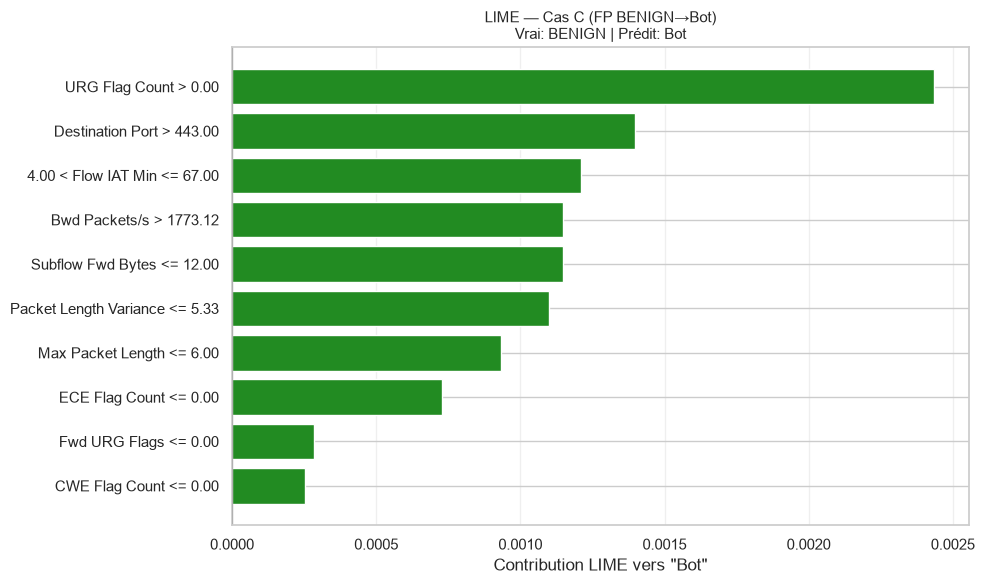


  CAS : Cas D (Misclassification)
  Vraie classe   : Web Attack
  Classe prédite : DoS
  Temps LIME     : 0.1s

📊 Top 10 features LIME (vers "DoS") :
  Idle Min <= 0.00                                   : -0.0145
  FIN Flag Count <= 0.00                             : -0.0095
  Bwd Packet Length Min <= 0.00                      : +0.0092
  53.00 < Destination Port <= 80.00                  : +0.0079
  Bwd Packet Length Std > 317.16                     : +0.0074
  Init_Win_bytes_backward > 235.00                   : +0.0062
  Fwd Header Length > 152.00                         : +0.0053
  2.00 < Total Backward Packets <= 5.00              : +0.0053
  Fwd URG Flags <= 0.00                              : -0.0035
  RST Flag Count <= 0.00                             : +0.0027


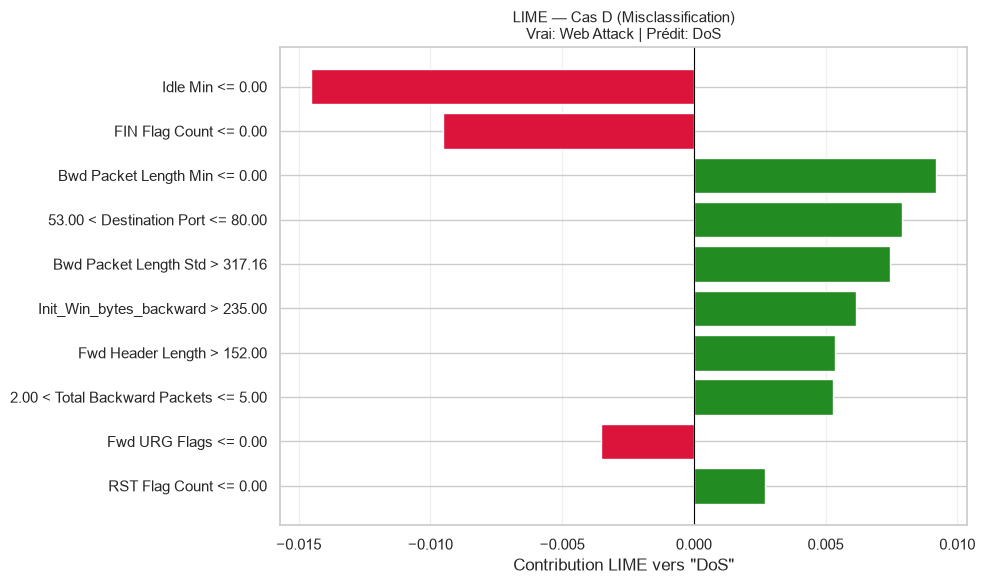

In [5]:
def explain_lime(case_idx, case_label, num_features=10):
    """Génère une explication LIME pour un cas."""
    if case_idx is None:
        return None
    
    true_cls = label_mapping[y_sample[case_idx]]
    pred_cls = label_mapping[y_sample_pred[case_idx]]
    pred_class_idx = class_names.index(pred_cls)
    
    t0 = time()
    exp = explainer_lime.explain_instance(
        data_row=X_sample[case_idx],
        predict_fn=xgb_model.predict_proba,
        num_features=num_features,
        labels=[pred_class_idx],
    )
    elapsed = time() - t0
    
    print(f'\n{"="*75}')
    print(f'  CAS : {case_label}')
    print(f'  Vraie classe   : {true_cls}')
    print(f'  Classe prédite : {pred_cls}')
    print(f'  Temps LIME     : {elapsed:.1f}s')
    print(f'{"="*75}')
    
    # Extraction des contributions LIME
    contribs = exp.as_list(label=pred_class_idx)
    print(f'\n📊 Top {num_features} features LIME (vers "{pred_cls}") :')
    for feat_desc, weight in contribs:
        sign = '+' if weight > 0 else ''
        print(f'  {feat_desc:50s} : {sign}{weight:.4f}')
    
    # Graphique
    fig, ax = plt.subplots(figsize=(10, 6))
    features_desc = [c[0] for c in contribs[::-1]]
    weights = [c[1] for c in contribs[::-1]]
    colors = ['crimson' if w < 0 else 'forestgreen' for w in weights]
    ax.barh(features_desc, weights, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f'Contribution LIME vers "{pred_cls}"')
    ax.set_title(f'LIME — {case_label}\nVrai: {true_cls} | Prédit: {pred_cls}', fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    safe_label = case_label.replace(' ', '_').replace('(', '').replace(')', '').replace('→', 'to')
    plt.savefig(RESULTS_FIGURES / f'09_lime_{safe_label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return contribs, exp

# Génération pour les 4 cas
lime_results = {}
for label, idx in cases.items():
    result = explain_lime(idx, label)
    if result is not None:
        lime_results[label] = result

## 6. Comparaison SHAP vs LIME — cas par cas

### 📚 La métrique de comparaison

Pour chaque cas, on récupère :
- Top 10 features selon **SHAP** (valeur absolue)
- Top 10 features selon **LIME** (valeur absolue)

Puis on calcule :
- **Overlap** : combien de features sont communes au top 10 des deux méthodes ?
- **Direction agreement** : pour les features communes, le sens (positif/négatif) est-il le même ?

In [6]:
def extract_lime_feature_names(lime_contribs):
    """Extrait les noms de features purs depuis les descriptions LIME.
    LIME renvoie 'Destination Port > 1024' au lieu de juste 'Destination Port'.
    On extrait le nom de feature."""
    feature_names = []
    for desc, _ in lime_contribs:
        # Trouve quelle feature correspond à la description
        matched = None
        for fc in feature_cols:
            if fc in desc:
                # Prend le plus long match (pour éviter 'Bwd Packets' qui match dans 'Bwd Packets/s')
                if matched is None or len(fc) > len(matched):
                    matched = fc
        feature_names.append(matched if matched else desc)
    return feature_names


def compare_shap_lime(case_idx, case_label, lime_contribs, top_k=10):
    """Compare les top features SHAP et LIME pour un cas."""
    pred_class_idx = class_names.index(label_mapping[y_sample_pred[case_idx]])
    
    # Top features SHAP
    shap_vals = shap_values[case_idx, :, pred_class_idx]
    shap_df = pd.DataFrame({
        'Feature': feature_cols,
        'SHAP': shap_vals,
        'SHAP_abs': np.abs(shap_vals),
    }).nlargest(top_k, 'SHAP_abs')
    
    # Top features LIME (extraction des noms purs)
    lime_feat_names = extract_lime_feature_names(lime_contribs)
    lime_weights = [w for _, w in lime_contribs]
    lime_df = pd.DataFrame({
        'Feature': lime_feat_names,
        'LIME': lime_weights,
        'LIME_abs': np.abs(lime_weights),
    })
    
    # Comparaison : intersection des top features
    shap_top_features = set(shap_df['Feature'])
    lime_top_features = set(lime_df['Feature'])
    common = shap_top_features & lime_top_features
    overlap_pct = 100 * len(common) / top_k
    
    # Pour les features communes : accord directionnel
    direction_agreement = 0
    for feat in common:
        shap_v = shap_df[shap_df['Feature'] == feat]['SHAP'].iloc[0]
        lime_v = lime_df[lime_df['Feature'] == feat]['LIME'].iloc[0]
        if np.sign(shap_v) == np.sign(lime_v):
            direction_agreement += 1
    direction_pct = 100 * direction_agreement / len(common) if common else 0
    
    print(f'\n{"="*75}')
    print(f'  COMPARAISON SHAP vs LIME — {case_label}')
    print(f'{"="*75}')
    print(f'\n📊 Top features SHAP :')
    print(shap_df[['Feature', 'SHAP']].to_string(index=False))
    print(f'\n📊 Top features LIME :')
    print(lime_df[['Feature', 'LIME']].to_string(index=False))
    print(f'\n🔍 Métriques de comparaison :')
    print(f'   Features communes (top {top_k}) : {len(common)}/{top_k} = {overlap_pct:.0f}%')
    if common:
        print(f'   Features communes : {sorted(common)}')
        print(f'   Accord directionnel : {direction_agreement}/{len(common)} = {direction_pct:.0f}%')
    
    return {
        'case': case_label,
        'overlap': overlap_pct,
        'direction_agreement': direction_pct,
        'common_features': sorted(common),
    }

comparison_results = []
for label, idx in cases.items():
    if idx is not None and label in lime_results:
        contribs, _ = lime_results[label]
        result = compare_shap_lime(idx, label, contribs, top_k=10)
        comparison_results.append(result)


  COMPARAISON SHAP vs LIME — Cas A (TP DDoS)

📊 Top features SHAP :
                    Feature      SHAP
       min_seg_size_forward  3.319405
Total Length of Bwd Packets  1.601635
    Init_Win_bytes_backward  1.075467
     Fwd Packet Length Mean  0.383248
          Subflow Bwd Bytes  0.325344
      Fwd Packet Length Max  0.270972
     Bwd Packet Length Mean  0.253168
          Fwd Header Length -0.200829
Total Length of Fwd Packets  0.191882
           act_data_pkt_fwd  0.184701

📊 Top features LIME :
                    Feature     LIME
           Destination Port 0.004092
                   Idle Std 0.003015
      Fwd Packet Length Std 0.002824
       min_seg_size_forward 0.002687
      Bwd Packet Length Std 0.002472
                Active Mean 0.002255
                   Idle Max 0.002242
Total Length of Fwd Packets 0.002084
                Bwd IAT Min 0.001917
              Flow Duration 0.001895

🔍 Métriques de comparaison :
   Features communes (top 10) : 2/10 = 20%
   Feature

### Visualisation comparative SHAP vs LIME (heatmap d'accord)

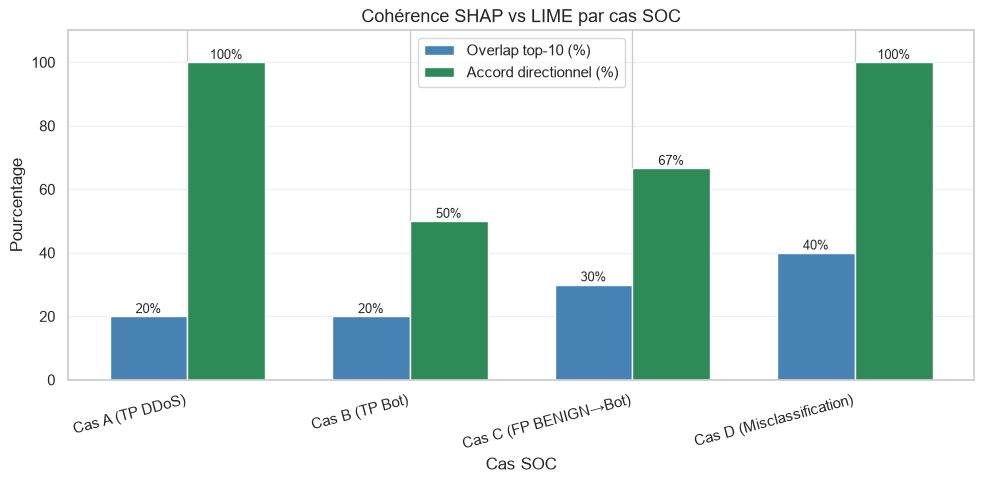

In [7]:
df_comp = pd.DataFrame(comparison_results)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_comp))
width = 0.35

bars1 = ax.bar(x - width/2, df_comp['overlap'], width, label='Overlap top-10 (%)', color='steelblue')
bars2 = ax.bar(x + width/2, df_comp['direction_agreement'], width, label='Accord directionnel (%)', color='seagreen')

ax.set_xlabel('Cas SOC')
ax.set_ylabel('Pourcentage')
ax.set_title('Cohérence SHAP vs LIME par cas SOC', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_comp['case'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis='y')

for bar, v in zip(bars1, df_comp['overlap']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
for bar, v in zip(bars2, df_comp['direction_agreement']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '09_shap_lime_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

df_comp.to_csv(RESULTS_METRICS / 'shap_lime_comparison_local.csv', index=False)

## 7. Métrique d'accord global SHAP vs LIME (50 cas aléatoires)

### 📚 Pourquoi cette étape

L'accord sur 4 cas est anecdotique. Pour un argument scientifique solide, on mesure l'accord sur un panel statistique : **50 cas aléatoires** du sample SHAP.

Cette analyse globale ira dans ton rapport comme **preuve quantitative** que les deux méthodes XAI sont (ou non) cohérentes sur ton modèle.

In [8]:
# Sélection de 50 cas aléatoires stratifiés
N_PANEL = 50
panel_indices = np.random.choice(len(X_sample), N_PANEL, replace=False)

print(f'🔬 Calcul LIME sur {N_PANEL} cas aléatoires...')
print('   (1-3s par cas, donc ~1-3 minutes)\n')

panel_overlaps = []
panel_directions = []
t0 = time()

for i, idx in enumerate(panel_indices):
    pred_class_idx = int(y_sample_pred[idx])
    
    # SHAP
    shap_vals = shap_values[idx, :, pred_class_idx]
    top_shap = pd.DataFrame({
        'Feature': feature_cols,
        'SHAP': shap_vals,
    }).assign(abs=lambda d: d['SHAP'].abs()).nlargest(10, 'abs')
    
    # LIME
    exp = explainer_lime.explain_instance(
        data_row=X_sample[idx],
        predict_fn=xgb_model.predict_proba,
        num_features=10,
        labels=[pred_class_idx],
    )
    contribs = exp.as_list(label=pred_class_idx)
    lime_feat_names = extract_lime_feature_names(contribs)
    lime_weights = [w for _, w in contribs]
    
    # Comparaison
    shap_set = set(top_shap['Feature'])
    lime_set = set(lime_feat_names)
    common = shap_set & lime_set
    overlap = len(common) / 10
    
    # Direction agreement sur les communes
    direction_agree = 0
    for feat in common:
        s_val = top_shap[top_shap['Feature'] == feat]['SHAP'].iloc[0]
        l_val = lime_weights[lime_feat_names.index(feat)]
        if np.sign(s_val) == np.sign(l_val):
            direction_agree += 1
    direction_pct = direction_agree / len(common) if common else 0
    
    panel_overlaps.append(overlap)
    panel_directions.append(direction_pct)
    
    if (i+1) % 10 == 0:
        print(f'  {i+1}/{N_PANEL} traités ({time()-t0:.1f}s écoulées)')

print(f'\n✅ Panel terminé en {(time()-t0)/60:.1f} min')

🔬 Calcul LIME sur 50 cas aléatoires...
   (1-3s par cas, donc ~1-3 minutes)

  10/50 traités (1.6s écoulées)
  20/50 traités (3.3s écoulées)
  30/50 traités (5.1s écoulées)
  40/50 traités (6.9s écoulées)
  50/50 traités (8.5s écoulées)

✅ Panel terminé en 0.1 min


In [9]:
# Statistiques globales
panel_overlaps = np.array(panel_overlaps)
panel_directions = np.array(panel_directions)

print('=' * 70)
print(f'  COHÉRENCE GLOBALE SHAP vs LIME (panel de {N_PANEL} cas)')
print('=' * 70)
print(f'\n📊 Overlap top-10 (intersection des features) :')
print(f'   Moyenne : {panel_overlaps.mean()*100:.1f}%')
print(f'   Médiane : {np.median(panel_overlaps)*100:.1f}%')
print(f'   Min     : {panel_overlaps.min()*100:.1f}%')
print(f'   Max     : {panel_overlaps.max()*100:.1f}%')
print(f'\n📊 Accord directionnel (sens des contributions communes) :')
print(f'   Moyenne : {panel_directions.mean()*100:.1f}%')
print(f'   Médiane : {np.median(panel_directions)*100:.1f}%')
print(f'   Min     : {panel_directions.min()*100:.1f}%')
print(f'   Max     : {panel_directions.max()*100:.1f}%')
print('=' * 70)

# Sauvegarde
panel_df = pd.DataFrame({
    'panel_idx': range(N_PANEL),
    'sample_idx': panel_indices,
    'overlap': panel_overlaps,
    'direction_agreement': panel_directions,
})
panel_df.to_csv(RESULTS_METRICS / 'shap_lime_panel_consistency.csv', index=False)

  COHÉRENCE GLOBALE SHAP vs LIME (panel de 50 cas)

📊 Overlap top-10 (intersection des features) :
   Moyenne : 27.4%
   Médiane : 30.0%
   Min     : 10.0%
   Max     : 40.0%

📊 Accord directionnel (sens des contributions communes) :
   Moyenne : 91.7%
   Médiane : 100.0%
   Min     : 50.0%
   Max     : 100.0%


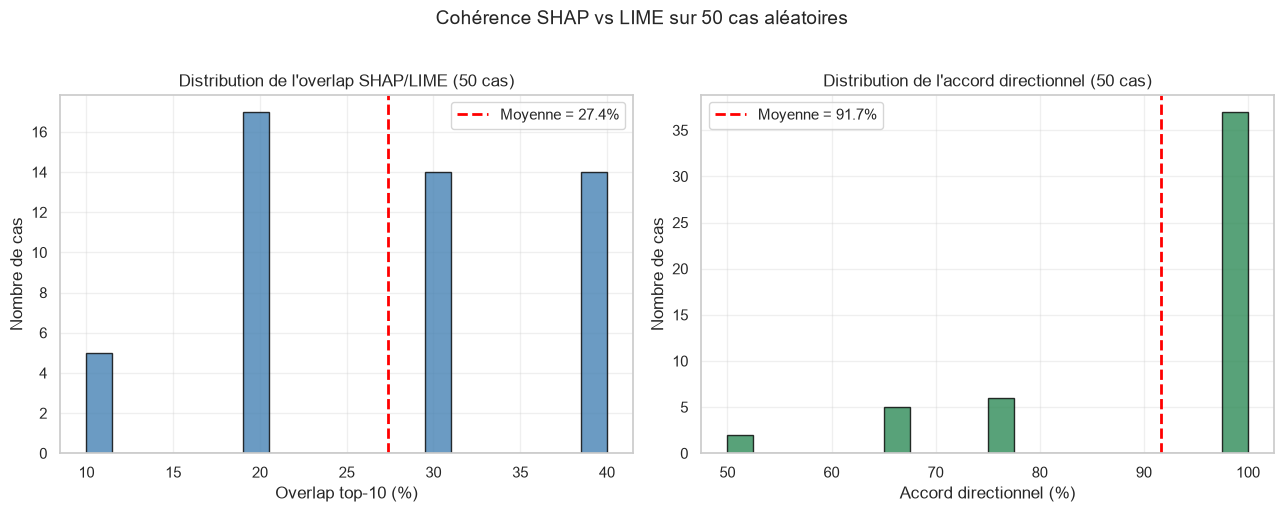

In [10]:
# Visualisation distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(panel_overlaps * 100, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(panel_overlaps.mean()*100, color='red', linewidth=2, linestyle='--', label=f'Moyenne = {panel_overlaps.mean()*100:.1f}%')
axes[0].set_xlabel('Overlap top-10 (%)')
axes[0].set_ylabel('Nombre de cas')
axes[0].set_title(f'Distribution de l\'overlap SHAP/LIME ({N_PANEL} cas)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(panel_directions * 100, bins=20, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].axvline(panel_directions.mean()*100, color='red', linewidth=2, linestyle='--', label=f'Moyenne = {panel_directions.mean()*100:.1f}%')
axes[1].set_xlabel('Accord directionnel (%)')
axes[1].set_ylabel('Nombre de cas')
axes[1].set_title(f'Distribution de l\'accord directionnel ({N_PANEL} cas)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Cohérence SHAP vs LIME sur 50 cas aléatoires', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '09_shap_lime_global_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sauvegarde des résultats LIME pour notebook 10

In [11]:
# Sauvegarde structurée des résultats LIME (les 4 cas + métriques)
import pickle

lime_export = {
    'cases': {k: v[0] if v else None for k, v in lime_results.items()},  # liste de (desc, weight)
    'comparison_results': comparison_results,
    'panel_overlaps': panel_overlaps.tolist(),
    'panel_directions': panel_directions.tolist(),
    'panel_indices': panel_indices.tolist(),
    'cases_indices': {k: int(v) if v is not None else None for k, v in cases.items()},
}

with open(RESULTS_XAI / 'lime_results.pkl', 'wb') as f:
    pickle.dump(lime_export, f)

print(f'✅ Résultats LIME sauvegardés : {RESULTS_XAI}/lime_results.pkl')
print(f'   - 4 explications locales (cas A, B, C, D)')
print(f'   - Comparaisons SHAP vs LIME par cas')
print(f'   - Panel d\'accord sur {N_PANEL} cas')

✅ Résultats LIME sauvegardés : ..\results\xai/lime_results.pkl
   - 4 explications locales (cas A, B, C, D)
   - Comparaisons SHAP vs LIME par cas
   - Panel d'accord sur 50 cas


## 🎉 Récapitulatif

Tu viens de produire **la première comparaison rigoureuse SHAP vs LIME** sur ton modèle.

### Outputs produits

**Figures :**
- `09_lime_*.png` : 4 explications LIME locales (cas A, B, C, D)
- `09_shap_lime_consistency.png` : cohérence par cas
- `09_shap_lime_global_distribution.png` : distribution sur panel

**Données :**
- `lime_results.pkl` : tout le matériel pour notebook 10
- `shap_lime_comparison_local.csv` : tableau de comparaison par cas
- `shap_lime_panel_consistency.csv` : résultats du panel global

### Question clé à retenir pour le rapport

**Si l'overlap est élevé (>60%) :** *"Les deux méthodes XAI convergent sur les explications, renforçant la confiance dans le modèle."*

**Si l'overlap est moyen (30-60%) :** *"Les deux méthodes XAI partagent un cœur commun de features importantes, mais divergent sur les détails — illustrant la nécessité de croiser plusieurs méthodes XAI en production."*

**Si l'overlap est faible (<30%) :** *"Les deux méthodes XAI divergent fortement, soulevant la question de la fiabilité des explications individuelles et la nécessité d'une évaluation de la qualité (notebook 10)."*

### Prochaine étape (notebook 10)

**Évaluation de la qualité des explications** : stabilité, fidélité, plausibilité.

C'est là que tu vas vraiment **trancher** : quelle méthode XAI est la plus fiable sur ton modèle ?